# Critical disorder $\sigma_c$ at fixed $\mu$ — locate per realization, then measure

The $\sigma$-analog of the $\mu_c$ workflow. Holding the mean interaction $\mu=0.2$ **fixed**, we
locate the critical disorder **per graph realization** and then **simulate each realization at its
own $\sigma_c$**, measuring the Moran--Secchi--Bouchaud size--volatility relation and the growth-rate
distribution on physical time.

**Locating $\sigma_c$ per realization (shape-scalar zero-crossing).** Mirrors
`glv.find_mu_c_shape_scalar` but sweeps $\sigma$ at fixed $\mu$. For each realization (a graph $A$
plus one frozen disorder draw $z$) and each $\sigma$, build
$W_{ij}=A_{ij}(\mu/C+(\sigma/\sqrt C)z_{ij})$, relax the shape $y$, and read
$$c=(y^*)^\top W\,y^* - (y^*)^\top y^*,$$
which fixes the sign of $\mathrm dM/\mathrm d\tau=1+cM$ ($c<0$ subcritical, $c>0$ supercritical). Each
realization has its **own** crossing $\sigma_c$; we report the whole distribution, not a single mean.

**Measuring each realization at its own $\sigma_c$ (physical-time MSB).** The earlier version pooled
every run at one *averaged* $\sigma_c=0.614$, which drove realizations whose true threshold was lower
(~0.49) well *past* their edge into the unbounded-growth regime — the growth distribution lost its
right (growth) tail and kept only the decay tail. Matching each realization to its own $\sigma_c$
removes that overshoot. For each realization we rebuild its exact graph $+\,z$, set $\sigma=\sigma_c$,
integrate from a random initial condition, resample on a uniform yearly **physical-time** grid, and
take $g_i=\Delta\ln S_i$. Relative size $S_i=N\,y_i/\sum_j y_j$ comes from the shape (the scale $M$
cancels, never overflows).

**Caveats.**
- $c(\sigma)$ is read on the subcritical side; above $\sigma_c$ the shape stops relaxing and $c$ turns
  noisy, so only the first crossing is meaningful (it is horizon-converged: identical at
  $\tau=10^4,10^5,3\times10^5$).
- At the critical point $M$ is marginal, so the physical-time window a run reaches is intrinsically
  limited; we report the per-run physical time and the growth-tail balance so any residual
  unbounded-regime signature is visible.
- Reproducible: the graph wiring, the disorder draw, and the initial conditions are all seeded.
- Failed integrations are dropped and counted.

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # spawn re-imports the kernel and breaks the pool

import os
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.integrate import solve_ivp
from scipy.stats import kurtosis, skew

import glv
glv.apply_style()

N           = 1000                          # species / firms
C           = 5                             # mean degree
MU          = 0.2                           # FIXED mean interaction
SIGMA_GRID  = np.linspace(0.3, 1.0, 20)     # locator sweep, brackets per-realization sigma_c
n_real      = 12                            # graph realizations (each gets its OWN sigma_c)
n_ic        = 2                             # initial conditions measured per realization
tau_loc     = 1e4                           # locator horizon (shape-scalar is horizon-converged)
m_cap       = 1e250                         # halt M before overflow
tau_meas    = 1e6                           # measurement trajectory horizon
n_years     = 100                           # physical-time yearly resample points
FLOOR       = 1e-3                          # live-firm threshold for binning
n_workers   = min(8, (mp.cpu_count() or 2))
LOC_RES     = "sigma_critical_locator.npz"
MEAS_RES    = "sigma_critical_at_sigmac.npz"
print(f"mu={MU} fixed | sigma grid [{SIGMA_GRID[0]:g},{SIGMA_GRID[-1]:g}] x{len(SIGMA_GRID)}"
      f" | {n_real} realizations x {n_ic} ICs | workers={n_workers}")

mu=0.2 fixed | sigma grid [0.3,1] x20 | 12 realizations x 2 ICs | workers=8


In [2]:
# Degree law: exponential, kept inline (project convention: no library wrapper).
# Fully seeded: configuration_model gets the seed too, so a realization is reproducible
# from (seed_graph, seed_z) alone -- the locator and the measurement rebuild the SAME graph.
def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg

def build_adjacency(seed_graph):
    rng = np.random.default_rng(seed_graph)
    deg = make_even(exponential_degrees(C, rng))
    G = nx.Graph(nx.configuration_model(list(deg), seed=int(seed_graph)))
    G.remove_edges_from(nx.selfloop_edges(G))
    return nx.to_scipy_sparse_array(G, format="csr", dtype=float)

def make_W(A_coo, z, sigma):
    # binary adjacency -> W_ij = A_ij (mu/C + sigma/sqrt(C) z_ij) on the edges.
    data = MU / C + (sigma / np.sqrt(C)) * z
    return sp.csr_array((data, (A_coo.row, A_coo.col)), shape=A_coo.shape)

In [3]:
# Per-realization sigma_c: shape-scalar zero-crossing (sigma-analog of find_mu_c_shape_scalar).
# Freeze z over the realization's graph, sweep sigma, read the relaxed-shape scalar
#   c = y*^T W y* - y*^T y*   (sign of dM/dtau = 1 + cM). An event halts at m_cap so
# supercritical runs still return a valid c instead of overflowing.
def c_of_W(W):
    def rhs(tau, s):
        y = np.clip(s[:N], 0.0, None)
        M = s[N]
        tot = y.sum()
        if tot > 0:
            y = y / tot
        F = W @ y
        phi = y @ F
        sq = y @ y
        dy = y * (F - phi - y + sq)
        dM = 0.0 if M >= m_cap else 1.0 + M * (phi - sq)
        return np.concatenate((dy, [dM], [1.0 / M]))

    def cap(tau, s):
        return s[N] - m_cap
    cap.terminal = True
    cap.direction = 1

    s0 = np.concatenate((np.full(N, 1.0 / N), [1.0], [0.0]))
    sol = solve_ivp(rhs, (0.0, tau_loc), s0, method="LSODA", rtol=1e-8, atol=1e-10,
                    events=cap, t_eval=[tau_loc])
    if not sol.success:
        return np.nan
    final = np.asarray(sol.y_events[0])[-1] if sol.t_events[0].size > 0 else np.asarray(sol.y)[:, -1]
    y = np.clip(np.asarray(final).ravel()[:N], 0.0, None)
    tot = y.sum()
    if tot <= 0:
        return np.nan
    y = y / tot
    return float(y @ (W @ y) - y @ y)

def first_crossing(sigmas, cs):
    good = np.isfinite(cs)
    m, c = sigmas[good], cs[good]
    sc = np.where(np.diff(np.sign(c)))[0]
    if sc.size == 0:
        return np.nan
    i = sc[0]
    return float(m[i] - c[i] * (m[i + 1] - m[i]) / (c[i + 1] - c[i]))

def _locate_one(args):
    seed_graph, seed_z = args
    A = build_adjacency(seed_graph).tocoo()
    z = np.random.default_rng(seed_z).standard_normal(A.row.size)
    cs = np.array([c_of_W(make_W(A, z, s)) for s in SIGMA_GRID])
    return cs, first_crossing(SIGMA_GRID, cs)

In [4]:
# Locate sigma_c for each realization; keep the per-realization values + seeds. Cache to .npz.
seed_graphs = 100 + np.arange(n_real)
seed_zs = 900 + np.arange(n_real)

if os.path.exists(LOC_RES):
    d = np.load(LOC_RES)
    c_curves, sigma_c_each = d["c_curves"], d["sigma_c_each"]
    seed_graphs, seed_zs = d["seed_graphs"], d["seed_zs"]
    print(f"loaded cache {LOC_RES}")
else:
    jobs = list(zip(seed_graphs.tolist(), seed_zs.tolist()))
    c_list, sc_list = [None] * n_real, [np.nan] * n_real
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = {ex.submit(_locate_one, j): i for i, j in enumerate(jobs)}
        for done, fut in enumerate(as_completed(futs), 1):
            i = futs[fut]
            cs, sc = fut.result()
            c_list[i], sc_list[i] = cs, sc
            print(f"  [{done}/{n_real}] realization {i} (graph={seed_graphs[i]}): sigma_c={sc:.4f}")
    c_curves = np.array(c_list)
    sigma_c_each = np.array(sc_list)
    np.savez(LOC_RES, c_curves=c_curves, sigma_c_each=sigma_c_each, sigma_grid=SIGMA_GRID,
             seed_graphs=seed_graphs, seed_zs=seed_zs)
    print(f"saved {LOC_RES}")

valid = np.isfinite(sigma_c_each)
print(f"\nper-realization sigma_c ({int(valid.sum())}/{n_real} crossed): "
      f"{np.array2string(np.sort(sigma_c_each[valid]), precision=3, separator=', ')}")
print(f"  median={np.median(sigma_c_each[valid]):.3f}  mean={np.mean(sigma_c_each[valid]):.3f}  "
      f"std={np.std(sigma_c_each[valid]):.3f}  range=[{sigma_c_each[valid].min():.3f}, "
      f"{sigma_c_each[valid].max():.3f}]")

  [1/12] realization 7 (graph=107): sigma_c=0.6483


  [2/12] realization 1 (graph=101): sigma_c=0.6262


  [3/12] realization 6 (graph=106): sigma_c=0.6400


  [4/12] realization 8 (graph=108): sigma_c=0.8419
  [5/12] realization 0 (graph=100): sigma_c=0.5636
  [6/12] realization 5 (graph=105): sigma_c=0.6696


  [7/12] realization 3 (graph=103): sigma_c=0.5220


  [8/12] realization 10 (graph=110): sigma_c=0.6897


  [9/12] realization 9 (graph=109): sigma_c=0.5579


  [10/12] realization 11 (graph=111): sigma_c=0.5292
  [11/12] realization 4 (graph=104): sigma_c=0.7097


  [12/12] realization 2 (graph=102): sigma_c=0.5221
saved sigma_critical_locator.npz

per-realization sigma_c (12/12 crossed): [0.522, 0.522, 0.529, 0.558, 0.564, 0.626, 0.64 , 0.648, 0.67 , 0.69 ,
 0.71 , 0.842]
  median=0.633  mean=0.627  std=0.091  range=[0.522, 0.842]


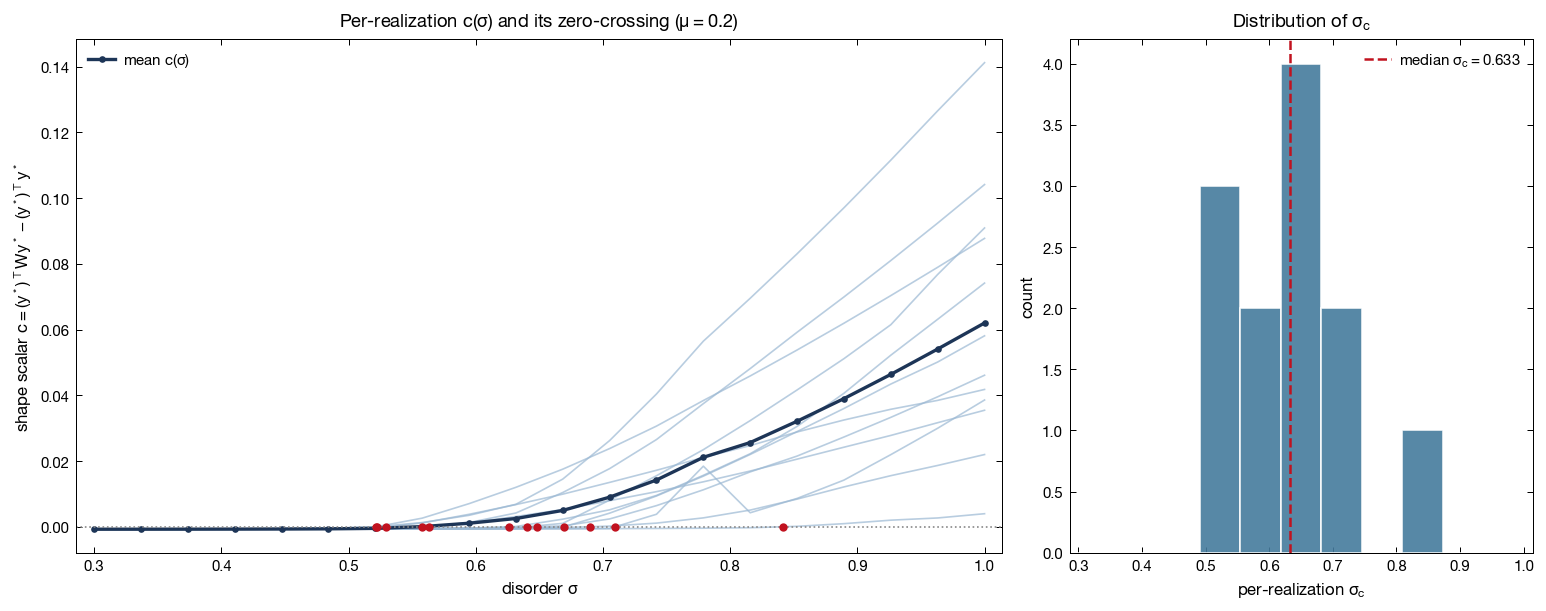

In [5]:
# Left: c(sigma) per realization with each zero-crossing. Right: distribution of sigma_c.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [2, 1]})
for cs, sc in zip(c_curves, sigma_c_each):
    axL.plot(SIGMA_GRID, cs, "-", color="#9bb8d3", lw=1, alpha=0.7)
    if np.isfinite(sc):
        axL.plot(sc, 0, "o", color="#c1121f", ms=5, zorder=5)
axL.plot(SIGMA_GRID, np.nanmean(c_curves, axis=0), "o-", color="#1d3557", lw=2,
         label=r"mean $c(\sigma)$")
axL.axhline(0, color="#888", lw=1, ls=":")
axL.set(xlabel=r"disorder $\sigma$",
        ylabel=r"shape scalar $c=(y^*)^\top W y^* - (y^*)^\top y^*$",
        title=rf"Per-realization $c(\sigma)$ and its zero-crossing ($\mu={MU}$)")
axL.legend()

med = np.median(sigma_c_each[valid])
axR.hist(sigma_c_each[valid], bins=np.linspace(0.3, 1.0, 12), color="#457b9d",
         edgecolor="white", alpha=0.9)
axR.axvline(med, color="#c1121f", lw=1.5, ls="--", label=rf"median $\sigma_c={med:.3f}$")
axR.set(xlabel=r"per-realization $\sigma_c$", ylabel="count",
        title=r"Distribution of $\sigma_c$")
axR.legend()
plt.tight_layout()
plt.savefig("sigma_critical_cofsigma.png", dpi=120)
plt.show()

In [6]:
# Measure each realization AT ITS OWN sigma_c on physical time. Rebuild the realization's exact
# graph + frozen z, set sigma = its sigma_c, integrate from n_ic random ICs. S = N*y/sum(y) from the
# shape (M cancels, no overflow); growth g = Delta ln S on a yearly physical-time grid (true MSB).
def run_one(W, x0):
    state0 = np.concatenate([x0 / x0.sum(), [x0.sum()], [0.0]])
    sol = solve_ivp(glv.rescaled_glv_sparse, (0.0, tau_meas), state0, args=(N, W),
                    method="RK45", max_step=1e2)
    if sol.t.size < 3:
        return None
    y = sol.y[:N, :]
    t_phys = sol.y[N + 1, :]
    t_final = t_phys[-1]
    if not np.isfinite(t_final) or t_final <= t_phys[0]:
        return None
    dt = (t_final - t_phys[0]) / n_years
    t_years = np.arange(t_phys[0], t_final, dt)
    y_yearly = np.array([np.interp(t_years, t_phys, y[k]) for k in range(N)])
    totals = y_yearly.sum(axis=0, keepdims=True)
    totals = np.where(totals > 0, totals, np.nan)
    S = N * y_yearly / totals
    log_S = np.log(np.maximum(S, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    sigma_i = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    return S.mean(axis=1), sigma_i, g.ravel(), float(t_final)

def _meas_job(args):
    seed_graph, seed_z, sigma_r, seed_ic = args
    A = build_adjacency(seed_graph).tocoo()
    z = np.random.default_rng(seed_z).standard_normal(A.row.size)
    W = make_W(A, z, sigma_r)
    x0 = np.random.default_rng(seed_ic).uniform(0.1, 1.0, N)
    res = run_one(W, x0)
    return sigma_r, res

if os.path.exists(MEAS_RES):
    d = np.load(MEAS_RES)
    avg_all, sig_all, g_all, tfin, sigc_of = (d["avg_all"], d["sig_all"], d["g_all"],
                                              d["tfin"], d["sigc_of"])
    dropped = int(d["dropped"])
    print(f"loaded cache {MEAS_RES}")
else:
    jobs = []
    for i in range(n_real):
        if not np.isfinite(sigma_c_each[i]):
            continue
        for j in range(n_ic):
            jobs.append((int(seed_graphs[i]), int(seed_zs[i]), float(sigma_c_each[i]), 5000 + 10 * i + j))
    avg_list, sig_list, g_list, tfin_list, sigc_list, dropped = [], [], [], [], [], 0
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_meas_job, j) for j in jobs]
        for done, fut in enumerate(as_completed(futs), 1):
            sig_r, res = fut.result()
            if res is None:
                dropped += 1
                print(f"  [{done}/{len(jobs)}] sigma_c={sig_r:.3f}: dropped")
            else:
                a, s, g, tf = res
                avg_list.append(a); sig_list.append(s); g_list.append(g)
                tfin_list.append(tf); sigc_list.append(sig_r)
                print(f"  [{done}/{len(jobs)}] sigma_c={sig_r:.3f}: ok (t_phys={tf:.3g} yr)")
    avg_all = np.concatenate(avg_list)
    sig_all = np.concatenate(sig_list)
    g_all = np.concatenate(g_list)
    tfin = np.array(tfin_list)
    sigc_of = np.array(sigc_list)
    np.savez(MEAS_RES, avg_all=avg_all, sig_all=sig_all, g_all=g_all, tfin=tfin,
             sigc_of=sigc_of, dropped=dropped)
    print(f"saved {MEAS_RES}")

print(f"\nmeasured at each realization's own sigma_c (median {np.median(sigc_of):.3f}): "
      f"{avg_all.size} firms, {dropped} runs dropped, {g_all.size} growth samples")
print(f"physical time reached: median={np.median(tfin):.3g} yr, "
      f"range [{tfin.min():.3g}, {tfin.max():.3g}] yr")

  [1/24] sigma_c=0.626: ok (t_phys=7.04 yr)
  [2/24] sigma_c=0.626: ok (t_phys=6.99 yr)


  [3/24] sigma_c=0.522: ok (t_phys=10.5 yr)
  [4/24] sigma_c=0.522: ok (t_phys=10.4 yr)


  [5/24] sigma_c=0.564: ok (t_phys=63.5 yr)
  [6/24] sigma_c=0.564: ok (t_phys=63.5 yr)


  [7/24] sigma_c=0.522: ok (t_phys=22.5 yr)
  [8/24] sigma_c=0.522: ok (t_phys=22.6 yr)


  [9/24] sigma_c=0.710: ok (t_phys=504 yr)


...

  [17/24] sigma_c=0.670: ok (t_phys=5.74 yr)
  [18/24] sigma_c=0.670: ok (t_phys=7.6 yr)
  [19/24] sigma_c=0.558: ok (t_phys=21.5 yr)


  [20/24] sigma_c=0.558: ok (t_phys=21.8 yr)


  [21/24] sigma_c=0.690: ok (t_phys=38 yr)


  [22/24] sigma_c=0.690: ok (t_phys=37.2 yr)


  [23/24] sigma_c=0.529: ok (t_phys=151 yr)
  [24/24] sigma_c=0.529: ok (t_phys=151 yr)
saved sigma_critical_at_sigmac.npz

measured at each realization's own sigma_c (median 0.633): 24000 firms, 0 runs dropped, 2376000 growth samples
physical time reached: median=29.9 yr, range [4.74, 504] yr


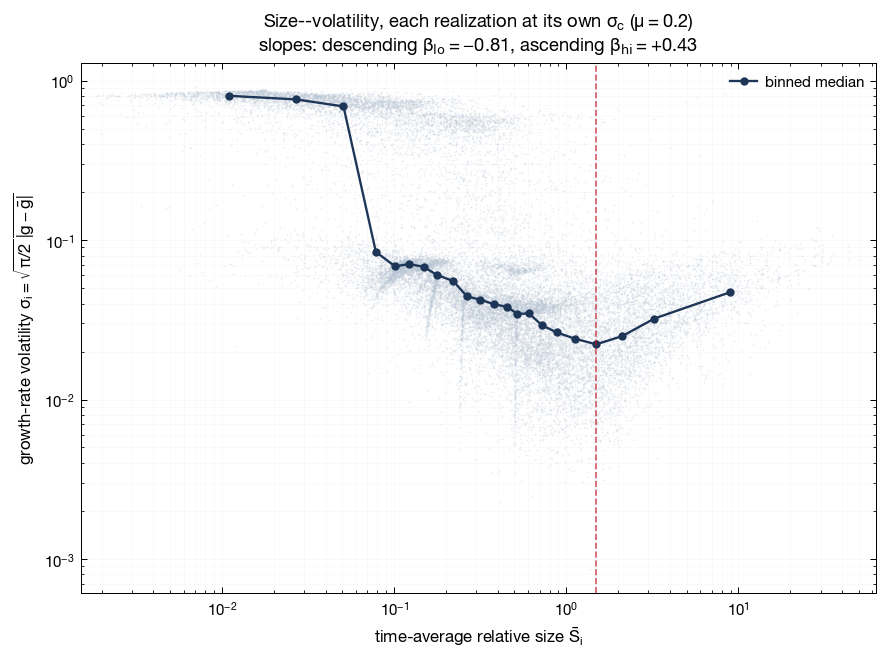

V-minimum at S~1.49; descending beta=-0.812, ascending beta=+0.427


In [7]:
# Plot 1: size-volatility relation pooled across realizations (each at its own sigma_c).
def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]),
            np.array([np.median(yp[p]) for p in parts]))

def two_slopes(x, y):
    bx, by = vbin(x, y)
    j = int(np.argmin(by))
    if j < 1 or j > len(bx) - 2:
        s = np.polyfit(np.log10(bx), np.log10(by), 1)[0]
        return bx[j], s, s
    lo = np.polyfit(np.log10(bx[:j + 1]), np.log10(by[:j + 1]), 1)[0]
    hi = np.polyfit(np.log10(bx[j:]), np.log10(by[j:]), 1)[0]
    return bx[j], lo, hi

live = (avg_all > FLOOR) & (sig_all > 0) & np.isfinite(sig_all)
bx, by = vbin(avg_all[live], sig_all[live])
smin, blo, bhi = two_slopes(avg_all[live], sig_all[live])

fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.loglog(avg_all[live], sig_all[live], ".", ms=2, color="#b8c6d6", alpha=0.3)
ax.loglog(bx, by, "o-", ms=5, color="#1d3557", label="binned median")
ax.axvline(smin, color="#c1121f", lw=1, ls="--", alpha=0.7)
ax.set(xlabel=r"time-average relative size $\bar S_i$",
       ylabel=r"growth-rate volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$",
       title=rf"Size--volatility, each realization at its own $\sigma_c$ ($\mu={MU}$)"
             + "\n" + rf"slopes: descending $\beta_{{\rm lo}}={blo:+.2f}$, ascending $\beta_{{\rm hi}}={bhi:+.2f}$")
ax.grid(True, which="both", alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("sigma_critical_volatility_size.png", dpi=120)
plt.show()
print(f"V-minimum at S~{smin:.3g}; descending beta={blo:+.3f}, ascending beta={bhi:+.3f}")

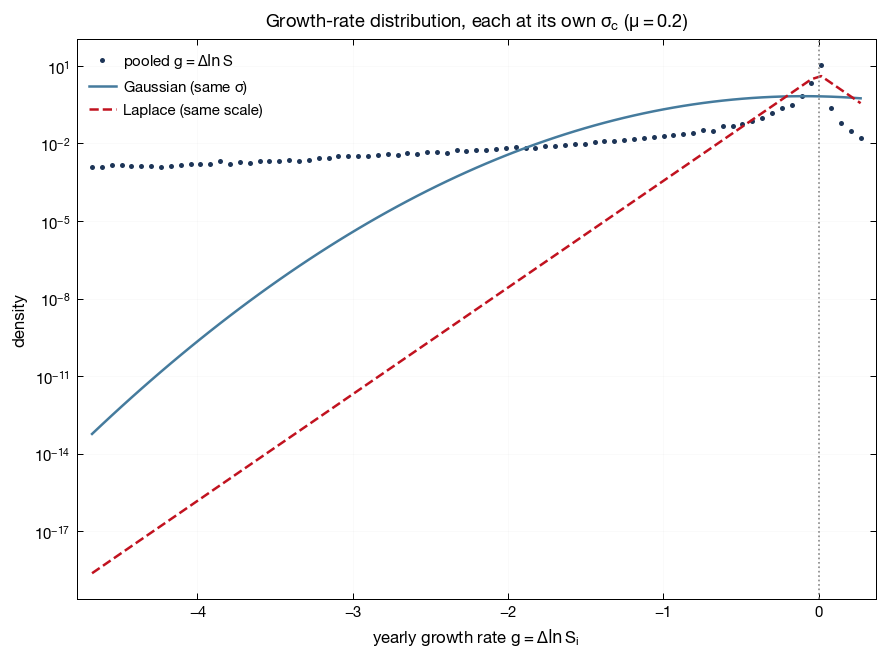

growth: mean=-0.0930, median=-0.0000, std=0.5911
  excess kurtosis=545.37 (0=Gaussian, 3=Laplace), skewness=-17.76
  tail mass beyond 2 std: right(growth)=0.03%  left(decay)=1.87%


In [8]:
# Plot 2: pooled growth-rate distribution vs Gaussian and Laplace, with explicit tail balance.
g = g_all[np.isfinite(g_all)]
mu_g, sd_g = g.mean(), g.std()
med_g = np.median(g)
b_lap = np.mean(np.abs(g - med_g))            # Laplace scale (MAD about the median)
gc = g - med_g
r_tail = np.mean(gc > 2 * sd_g)               # mass in the right (growth) tail
l_tail = np.mean(gc < -2 * sd_g)              # mass in the left (decay) tail

lo, hi = np.percentile(g, [0.3, 99.7])
edges = np.linspace(lo, hi, 80)
centers = 0.5 * (edges[:-1] + edges[1:])
dens, _ = np.histogram(g, bins=edges, density=True)
gauss = np.exp(-0.5 * ((centers - mu_g) / sd_g) ** 2) / (sd_g * np.sqrt(2 * np.pi))
lap = np.exp(-np.abs(centers - med_g) / b_lap) / (2 * b_lap)

fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.semilogy(centers, np.where(dens > 0, dens, np.nan), "o", ms=3, color="#1d3557",
            label=r"pooled $g=\Delta\ln S$")
ax.semilogy(centers, gauss, "-", color="#457b9d", lw=1.5, label=r"Gaussian (same $\sigma$)")
ax.semilogy(centers, lap, "--", color="#c1121f", lw=1.5, label="Laplace (same scale)")
ax.axvline(med_g, color="#888", lw=1, ls=":")
ax.set(xlabel=r"yearly growth rate $g=\Delta\ln S_i$", ylabel="density",
       title=rf"Growth-rate distribution, each at its own $\sigma_c$ ($\mu={MU}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("sigma_critical_growth_dist.png", dpi=120)
plt.show()

print(f"growth: mean={mu_g:+.4f}, median={med_g:+.4f}, std={sd_g:.4f}")
print(f"  excess kurtosis={kurtosis(g):.2f} (0=Gaussian, 3=Laplace), skewness={skew(g):+.2f}")
print(f"  tail mass beyond 2 std: right(growth)={100*r_tail:.2f}%  left(decay)={100*l_tail:.2f}%")

## Summary

_Filled in after execution._